<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/capacity_cost_fig1_fig2_reproduction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproduction of Figure 1 and Figure 2

**Paper:** *Capacity and Cost Investigations of Long-Span-Length, High-Number Spatial-Pairs Trans-Oceanic Cables*  
**Authors:** Silas Lasak Hedeboe et al., SubOptic 2025

이 노트북은 첨부 논문의 Figure 1과 Figure 2를 하나의 Colab에서 재현한다. 계산 결과는 논문의 그림에서 디지타이즈한 기준점과 같은 그래프에 겹쳐 표시한다.

- 실선: 논문 식 (2)-(5), (8)과 저자 제공 Python 함수에 기반한 계산
- 원형 마커: PDF 그림에서 디지타이즈한 논문 기준값
- 비교표: RMSE, MAE, 최대 절대오차

모든 계산은 이 노트북 안에서 수행되며, 외부 `.py` 파일이나 값 배열을 불러오지 않는다.


## 재현 범위와 중요한 가정

Figure 1은 저자 제공 `SNR_GD` 구현에 필요한 입력이 모두 논문에 있어 직접 재현할 수 있다.

Figure 2용 저자 함수 `optimized_capacity_extended`는 외부의 2차원 효율 표 `eta(gain, amplifier output power)`를 요구한다. 그러나 그 표와 `help_functions.py`는 첨부 자료에 포함되지 않았다. 따라서 아래에서는:

1. dB 변환 함수는 노트북 내부에서 다시 구현하고,
2. 누락된 `eta` 표는 gain과 출력전력에 따라 변하는 **투명한 해석식 surrogate**로 대체하며,
3. surrogate 부분을 한 함수로 분리해 실제 저자 표를 받으면 즉시 교체할 수 있게 한다.

따라서 Figure 1은 직접 재현이고, Figure 2는 같은 GN/generalized-droop 및 전력 제약 알고리즘을 사용한 **근사 재현**이다. 디지타이즈 오차는 대략 ±0.2~0.3 dB 수준일 수 있다.


In [1]:
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9.5, 6.0),
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 8.5,
    "lines.linewidth": 2.0,
})

def db_to_lin(x_db):
    return 10.0 ** (np.asarray(x_db, dtype=float) / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(np.asarray(x, dtype=float))

def dbm_to_w(x_dbm):
    return 1e-3 * db_to_lin(x_dbm)

def w_to_dbm(x_w):
    return lin_to_db(np.asarray(x_w, dtype=float) / 1e-3)


In [2]:
@dataclass(frozen=True)
class SystemParameters:
    # Fibre and amplifier parameters used for Figure 1/2
    attenuation_db_per_km: float = 0.15
    dispersion_s_per_km_nm: float = -21e-12
    gamma_per_w_km: float = 0.81
    noise_figure_db: float = 4.5
    wavelength_nm: float = 1550.0
    symbol_rate_hz: float = 100e9
    channel_spacing_hz: float = 112.5e9
    bandwidth_hz: float = 4.3e12
    gamma_xt_per_km: float = 0.0
    fifo_loss_db_each: float = 0.0

    # Figure 2 power-feed assumptions
    pfe_voltage_v: float = 18e3
    conductor_resistance_ohm_per_km: float = 1.0
    circuit_fraction: float = 0.10
    fibre_pairs: int = 12
    cores_per_fibre: int = 1
    nl_backoff_db: float = 2.0
    launch_power_limit_dbm: float = 18.0

    @property
    def effective_channel_count(self):
        # Matches the supplied author code: N_ch = B / delta_f.
        return self.bandwidth_hz / self.channel_spacing_hz


P = SystemParameters()

parameter_table = pd.DataFrame([
    ("alpha", P.attenuation_db_per_km, "dB/km"),
    ("D", P.dispersion_s_per_km_nm / 1e-12, "ps/(km nm)"),
    ("gamma", P.gamma_per_w_km, "1/(W km)"),
    ("NF", P.noise_figure_db, "dB"),
    ("lambda", P.wavelength_nm, "nm"),
    ("Rs", P.symbol_rate_hz / 1e9, "GBaud"),
    ("Delta f", P.channel_spacing_hz / 1e9, "GHz"),
    ("B", P.bandwidth_hz / 1e12, "THz"),
    ("effective Nch", P.effective_channel_count, "channels"),
    ("PFE voltage", P.pfe_voltage_v / 1e3, "kV"),
    ("fibre pairs", P.fibre_pairs, "pairs"),
], columns=["Parameter", "Value", "Unit"])
print(parameter_table.to_string(index=False))


    Parameter       Value       Unit
        alpha    0.150000      dB/km
            D  -21.000000 ps/(km nm)
        gamma    0.810000   1/(W km)
           NF    4.500000         dB
       lambda 1550.000000         nm
           Rs  100.000000      GBaud
      Delta f  112.500000        GHz
            B    4.300000        THz
effective Nch   38.222222   channels
  PFE voltage   18.000000         kV
  fibre pairs   12.000000      pairs


## GSNR 계산 알고리즘

논문과 저자 코드의 핵심은 다음 순서다.

1. $N=\lfloor L_{tot}/L_{span}\rfloor$로 repeater/span 수를 계산한다.
2. 실제 계산 span은 $L_{tot}/N$으로 둔다.
3. EDFA ASE: $P_{ASE}=hf_0 NF(G-1)R_s$
4. 식 (5)의 closed-form GN 모델로 span당 비선형 계수 $\alpha_{NL}$을 계산한다.
5. additive droop $\chi_a$와 redistribution droop $\chi_r$를 식 (3), (4)로 계산한다.
6. 전체 GSNR은 식 (2)로 누적한다.

아래 구현은 저자 제공 `SNR_GD`와 같은 수식을 사용하되, 큰 span 수에서 overflow가 나지 않도록 로그 영역에서 누적한다.


In [3]:
H = 6.62607015e-34       # J s
C_NM_PER_S = 2.99792458e17


def span_count_and_length(total_length_km, nominal_span_km):
    n_spans = max(1, int(np.floor(total_length_km / nominal_span_km)))
    actual_span_km = total_length_km / n_spans
    return n_spans, actual_span_km


def gn_alpha_nli(actual_span_km, params=P):
    alpha_lin = params.attenuation_db_per_km / 4.343
    beta2 = (
        -params.dispersion_s_per_km_nm
        * params.wavelength_nm**2
        / (2.0 * np.pi * C_NM_PER_S)
    )
    leff = (1.0 - np.exp(-alpha_lin * actual_span_km)) / alpha_lin
    leff_asymptotic = 1.0 / alpha_lin
    nch = params.effective_channel_count

    asinh_arg = (
        np.pi**2 / 2.0
        * abs(beta2)
        * leff_asymptotic
        * params.symbol_rate_hz**2
        * nch ** (2.0 * params.symbol_rate_hz / params.channel_spacing_hz)
    )
    return (
        (8.0 / 27.0)
        * params.gamma_per_w_km**2
        * leff**2
        * np.arcsinh(asinh_arg)
        / (
            np.pi
            * abs(beta2)
            * leff_asymptotic
            * params.symbol_rate_hz**2
        )
    )


def generalized_droop_gsnr(total_launch_power_w, total_length_km, nominal_span_km, params=P):
    ps = np.asarray(total_launch_power_w, dtype=float)
    n_spans, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    nch = params.effective_channel_count
    pch = ps / nch

    centre_frequency_hz = C_NM_PER_S / params.wavelength_nm
    nf_linear = db_to_lin(params.noise_figure_db)
    span_loss_db = (
        params.attenuation_db_per_km * actual_span_km
        + 2.0 * params.fifo_loss_db_each
    )
    gain_linear = db_to_lin(span_loss_db)
    pase = (
        H
        * centre_frequency_hz
        * nf_linear
        * params.symbol_rate_hz
        * (gain_linear - 1.0)
    )
    chi_a = 1.0 / (1.0 + pase / pch)

    alpha_nli = gn_alpha_nli(actual_span_km, params)
    inv_snr_1span_nli = alpha_nli * pch**2
    inv_snr_1span_xt = params.gamma_xt_per_km * actual_span_km
    chi_r = 1.0 / (1.0 + inv_snr_1span_nli + inv_snr_1span_xt)

    exponent = n_spans * (-np.log(chi_a) - np.log(chi_r))
    denominator = np.empty_like(exponent, dtype=float)
    safe = exponent < 700.0
    denominator[safe] = np.expm1(exponent[safe])
    denominator[~safe] = np.inf
    return 1.0 / denominator


# Sanity check: all outputs must be finite and positive in the plotted Figure 1 domain.
_test = generalized_droop_gsnr(dbm_to_w(np.linspace(0, 30, 61)), 6000, 100)
assert np.all(np.isfinite(_test)) and np.all(_test > 0)
print("GSNR model sanity check: PASS")


GSNR model sanity check: PASS


## Figure 1 - GSNR versus total launch power

총 길이 6000 km, span length 50/100/150 km에 대해 0~30 dBm의 **전체 WDM launch power**를 sweep한다. 계산 결과는 연속 실선이고, 논문 PDF에서 읽은 기준점은 빈 원형 마커다.


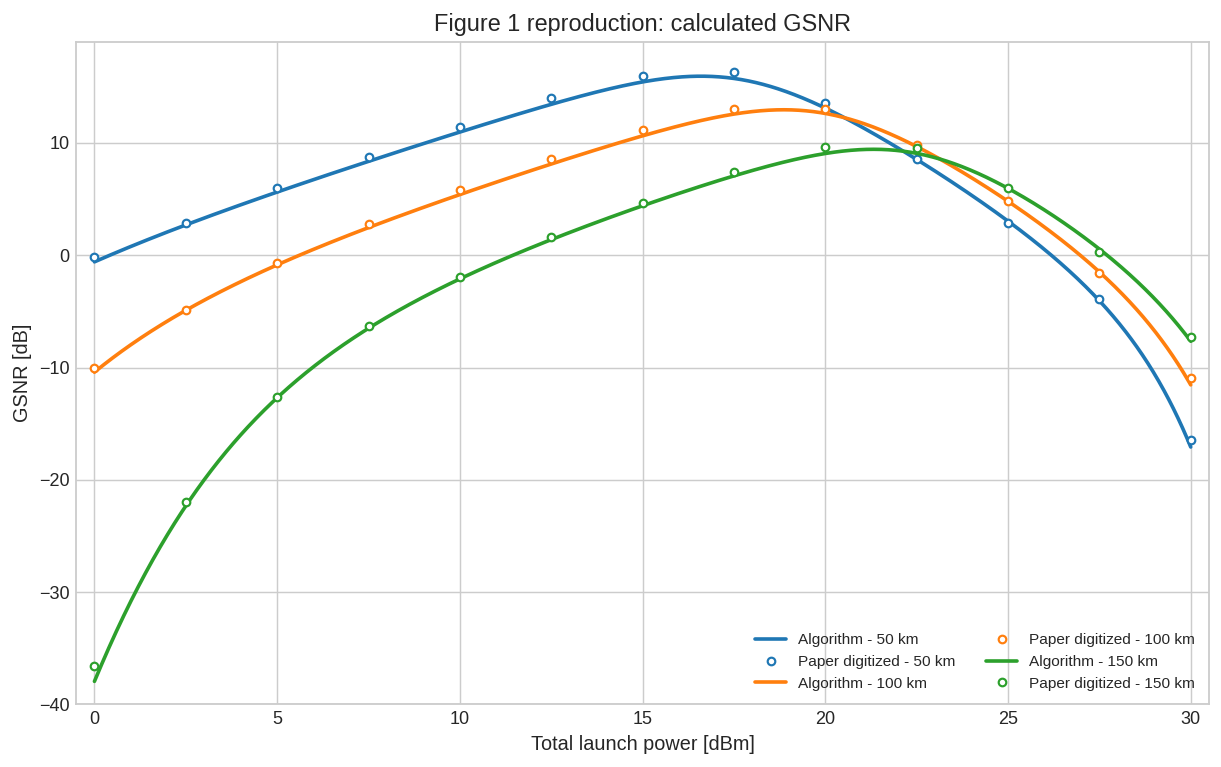

 Span (km)  RMSE (dB)  MAE (dB)  Max |error| (dB)  Calculated peak (dB)  Calculated peak power (dBm)
        50      0.420     0.378             0.627                15.940                       16.600
       100      0.362     0.318             0.574                12.950                       18.850
       150      0.486     0.368             1.335                 9.432                       21.325


In [4]:
# Digitized reference points from Figure 1 of the supplied PDF.
fig1_paper = {
    50: {
        "x_dbm": np.arange(0.0, 30.1, 2.5),
        "y_db": np.array([-0.16, 2.90, 5.97, 8.71, 11.45, 14.03, 15.97,
                          16.29, 13.55, 8.55, 2.90, -3.87, -16.45]),
    },
    100: {
        "x_dbm": np.arange(0.0, 30.1, 2.5),
        "y_db": np.array([-10.00, -4.84, -0.65, 2.74, 5.81, 8.55, 11.13,
                          13.06, 13.06, 9.84, 4.84, -1.61, -10.97]),
    },
    150: {
        "x_dbm": np.arange(0.0, 30.1, 2.5),
        "y_db": np.array([-36.61, -21.94, -12.58, -6.29, -1.94, 1.61, 4.68,
                          7.42, 9.68, 9.52, 5.97, 0.32, -7.26]),
    },
}

launch_dbm = np.linspace(0.0, 30.0, 1201)
launch_w = dbm_to_w(launch_dbm)
fig1_metrics = []

fig, ax = plt.subplots()
for color_index, span_km in enumerate((50, 100, 150)):
    colour = f"C{color_index}"
    calc_db = lin_to_db(generalized_droop_gsnr(launch_w, 6000, span_km))
    ref = fig1_paper[span_km]
    calc_at_ref = np.interp(ref["x_dbm"], launch_dbm, calc_db)
    error = calc_at_ref - ref["y_db"]
    fig1_metrics.append({
        "Span (km)": span_km,
        "RMSE (dB)": np.sqrt(np.mean(error**2)),
        "MAE (dB)": np.mean(np.abs(error)),
        "Max |error| (dB)": np.max(np.abs(error)),
        "Calculated peak (dB)": np.max(calc_db),
        "Calculated peak power (dBm)": launch_dbm[np.argmax(calc_db)],
    })

    ax.plot(launch_dbm, calc_db, color=colour,
            label=f"Algorithm - {span_km} km")
    ax.plot(ref["x_dbm"], ref["y_db"], linestyle="none", marker="o",
            markersize=4.2, markerfacecolor="white", markeredgewidth=1.2,
            color=colour, label=f"Paper digitized - {span_km} km")

ax.set_title("Figure 1 reproduction: calculated GSNR")
ax.set_xlabel("Total launch power [dBm]")
ax.set_ylabel("GSNR [dB]")
ax.set_xlim(-0.5, 30.5)
ax.set_ylim(-40, 19)
ax.legend(ncol=2, loc="lower right")
fig.tight_layout()
plt.show()

fig1_metrics = pd.DataFrame(fig1_metrics)
print(fig1_metrics.round(3).to_string(index=False))


## Figure 2 - power constraints and optimal operating power

각 nominal span에서 먼저 제약이 없는 GSNR 최대점 $P_{NL}$을 계산한다. 실제 운전 power는 다음 세 값 중 가장 작은 값이다.

- 논문의 운전 기준: $P_{NL}-2$ dB
- 하드웨어 상한: 18 dBm
- PFE 상한: 식 (8)을 만족하는 최대 power

저자 코드가 요구하는 누락된 2차원 효율 표 대신 아래 surrogate를 사용한다. 이 함수는 낮은 EDFA gain/출력에서는 pump와 driver가 비효율적이고, gain/출력이 증가하면 효율이 포화되는 특성을 sigmoid 두 개로 나타낸다. **정확한 저자 `eta` 배열을 확보하면 `eta_eo_surrogate()`만 교체하면 된다.**


In [5]:
def eta_eo_surrogate(gain_db, total_output_power_w):
    '''Transparent replacement for the missing author eta[gain, output] table.'''
    pout_dbm = w_to_dbm(total_output_power_w)

    # Gain-dependent EDFA optical efficiency: low at small gain, saturating at high gain.
    eta_gain = 0.011 + 0.012 / (1.0 + np.exp(-(gain_db - 5.5) / 1.7))

    # Electrical/pump efficiency rolls off strongly at very low amplifier output.
    eta_output = 0.58 + 0.42 / (1.0 + np.exp(-(pout_dbm - 12.0) / 1.5))
    return np.clip(eta_gain * eta_output, 0.004, 0.024)


power_search_dbm = np.linspace(-30.0, 30.0, 3001)
power_search_w = dbm_to_w(power_search_dbm)


def optimize_span_point(total_length_km, nominal_span_km, params=P):
    n_spans, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    gsnr_curve = generalized_droop_gsnr(
        power_search_w, total_length_km, nominal_span_km, params
    )
    p_nl_w = power_search_w[np.argmax(gsnr_curve)]
    p_backoff_w = p_nl_w / db_to_lin(params.nl_backoff_db)
    p_hardware_w = dbm_to_w(params.launch_power_limit_dbm)

    gain_db = (
        params.attenuation_db_per_km * actual_span_km
        + 2.0 * params.fifo_loss_db_each
    )
    eta_candidates = eta_eo_surrogate(gain_db, power_search_w)
    pfe_coefficient = (
        params.pfe_voltage_v**2
        * (1.0 - params.circuit_fraction)
        / (4.0 * params.conductor_resistance_ohm_per_km * total_length_km)
        / (n_spans * 2.0 * params.fibre_pairs * params.cores_per_fibre)
    )
    feasible = power_search_w <= pfe_coefficient * eta_candidates
    p_pfe_w = power_search_w[np.where(feasible)[0][-1]]

    limits = {
        "PFE": p_pfe_w,
        "NL-2 dB": p_backoff_w,
        "18 dBm": p_hardware_w,
    }
    active_constraint = min(limits, key=limits.get)
    p_used_w = limits[active_constraint]
    gsnr_used = generalized_droop_gsnr(
        np.array([p_used_w]), total_length_km, nominal_span_km, params
    )[0]
    return {
        "nominal_span_km": float(nominal_span_km),
        "actual_span_km": actual_span_km,
        "n_spans": n_spans,
        "gain_db": gain_db,
        "eta_eo": float(eta_eo_surrogate(gain_db, p_used_w)),
        "p_nl_dbm": float(w_to_dbm(p_nl_w)),
        "p_pfe_dbm": float(w_to_dbm(p_pfe_w)),
        "p_used_dbm": float(w_to_dbm(p_used_w)),
        "active_constraint": active_constraint,
        "gsnr_db": float(lin_to_db(gsnr_used)),
    }


# Smoke test for all four Figure 2 distances.
for _length in (6000, 9000, 12000, 15000):
    _point = optimize_span_point(_length, 75)
    assert np.isfinite(_point["gsnr_db"])
print("Figure 2 optimizer sanity check: PASS")


Figure 2 optimizer sanity check: PASS


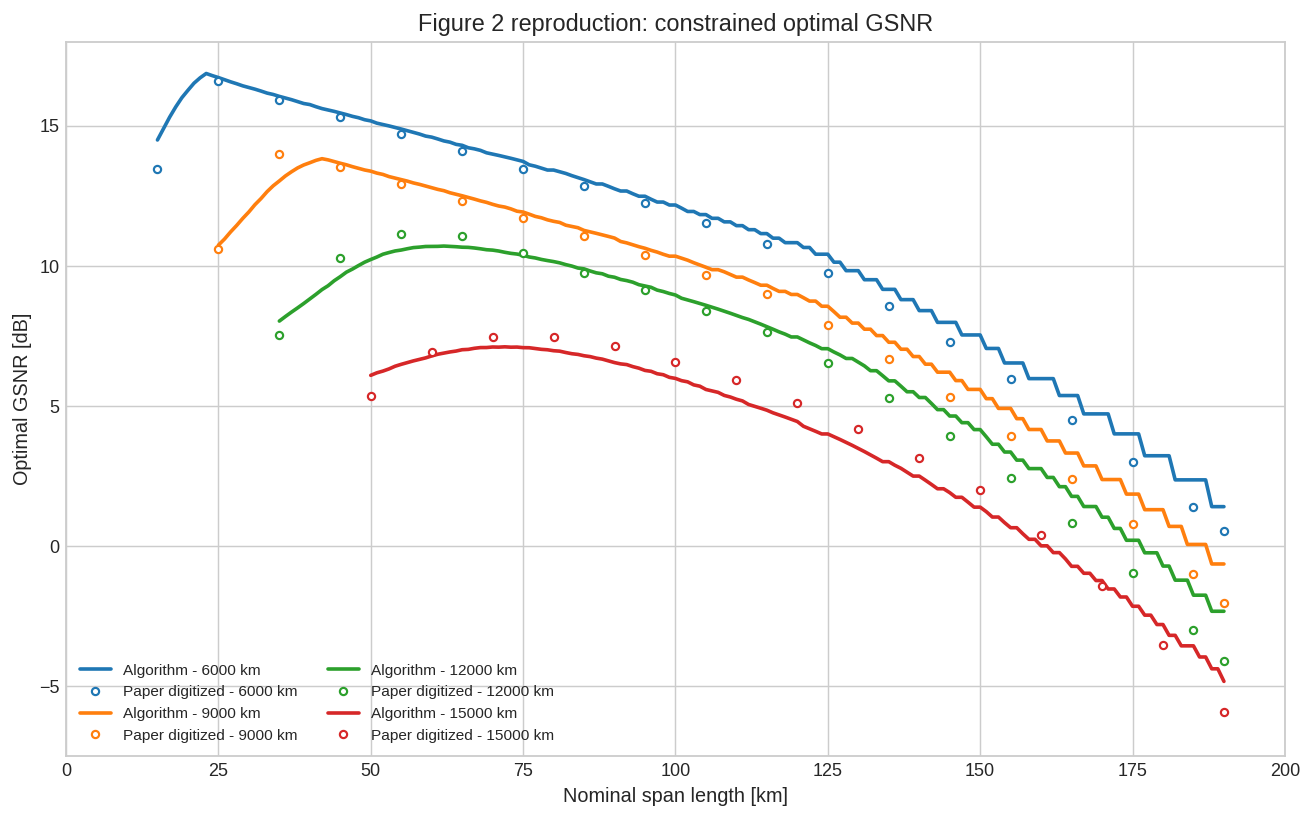

In [6]:
# Digitized reference points from Figure 2 of the supplied PDF.
fig2_paper = {
    6000: {
        "x_km": np.array([15, 25, 35, 45, 55, 65, 75, 85, 95, 105,
                          115, 125, 135, 145, 155, 165, 175, 185, 190]),
        "y_db": np.array([13.48, 16.59, 15.93, 15.31, 14.72, 14.10, 13.48,
                          12.86, 12.24, 11.55, 10.79, 9.76, 8.59, 7.28, 5.97,
                          4.52, 3.00, 1.41, 0.55]),
    },
    9000: {
        "x_km": np.array([25, 35, 45, 55, 65, 75, 85, 95, 105, 115,
                          125, 135, 145, 155, 165, 175, 185, 190]),
        "y_db": np.array([10.62, 14.00, 13.55, 12.93, 12.31, 11.72, 11.07,
                          10.41, 9.69, 9.00, 7.90, 6.69, 5.34, 3.93, 2.41,
                          0.79, -1.00, -2.03]),
    },
    12000: {
        "x_km": np.array([35, 45, 55, 65, 75, 85, 95, 105, 115, 125,
                          135, 145, 155, 165, 175, 185, 190]),
        "y_db": np.array([7.55, 10.28, 11.14, 11.07, 10.45, 9.76, 9.14,
                          8.38, 7.66, 6.55, 5.28, 3.93, 2.45, 0.83, -0.97,
                          -2.97, -4.10]),
    },
    15000: {
        "x_km": np.array([50, 60, 70, 80, 90, 100, 110, 120, 130, 140,
                          150, 160, 170, 180, 190]),
        "y_db": np.array([5.38, 6.93, 7.48, 7.48, 7.14, 6.59, 5.93, 5.10,
                          4.17, 3.14, 2.00, 0.41, -1.41, -3.52, -5.93]),
    },
}

span_grid_km = np.arange(5, 191, 1)
fig2_results = {}

for total_length_km in fig2_paper:
    rows = [optimize_span_point(total_length_km, span) for span in span_grid_km]
    fig2_results[total_length_km] = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10.2, 6.4))
for color_index, total_length_km in enumerate((6000, 9000, 12000, 15000)):
    colour = f"C{color_index}"
    result = fig2_results[total_length_km]
    ref = fig2_paper[total_length_km]
    visible = result["nominal_span_km"] >= ref["x_km"].min()

    ax.plot(result.loc[visible, "nominal_span_km"], result.loc[visible, "gsnr_db"],
            color=colour, label=f"Algorithm - {total_length_km} km")
    ax.plot(ref["x_km"], ref["y_db"], linestyle="none", marker="o",
            markersize=4.0, markerfacecolor="white", markeredgewidth=1.2,
            color=colour, label=f"Paper digitized - {total_length_km} km")

ax.set_title("Figure 2 reproduction: constrained optimal GSNR")
ax.set_xlabel("Nominal span length [km]")
ax.set_ylabel("Optimal GSNR [dB]")
ax.set_xlim(0, 200)
ax.set_ylim(-7.5, 18.0)
ax.set_xticks(np.arange(0, 201, 25))
ax.legend(ncol=2, loc="lower left")
fig.tight_layout()
plt.show()


In [7]:
fig2_metrics = []
transition_rows = []

for total_length_km, ref in fig2_paper.items():
    result = fig2_results[total_length_km]
    calc_at_ref = np.interp(
        ref["x_km"], result["nominal_span_km"], result["gsnr_db"]
    )
    error = calc_at_ref - ref["y_db"]
    visible = result["nominal_span_km"] >= ref["x_km"].min()
    visible_result = result.loc[visible]
    peak_row = visible_result.loc[visible_result["gsnr_db"].idxmax()]

    fig2_metrics.append({
        "Total length (km)": total_length_km,
        "RMSE (dB)": np.sqrt(np.mean(error**2)),
        "MAE (dB)": np.mean(np.abs(error)),
        "Max |error| (dB)": np.max(np.abs(error)),
        "Calculated peak span (km)": peak_row["nominal_span_km"],
        "Calculated peak GSNR (dB)": peak_row["gsnr_db"],
    })

    constraints = visible_result["active_constraint"].to_numpy()
    spans = visible_result["nominal_span_km"].to_numpy()
    change_indices = np.r_[0, np.where(constraints[1:] != constraints[:-1])[0] + 1]
    transition_text = ", ".join(
        f"{constraints[i]} from {spans[i]:.0f} km" for i in change_indices
    )
    transition_rows.append({
        "Total length (km)": total_length_km,
        "Active-constraint sequence": transition_text,
    })

fig2_metrics = pd.DataFrame(fig2_metrics)
transition_table = pd.DataFrame(transition_rows)

print("Figure 2 numerical comparison")
print(fig2_metrics.round(3).to_string(index=False))
print("\nCalculated active-constraint transitions")
print(transition_table.to_string(index=False))


Figure 2 numerical comparison
 Total length (km)  RMSE (dB)  MAE (dB)  Max |error| (dB)  Calculated peak span (km)  Calculated peak GSNR (dB)
              6000      0.589     0.495             1.018                       23.0                     16.870
              9000      0.704     0.574             1.398                       42.0                     13.830
             12000      0.776     0.633             1.781                       62.0                     10.713
             15000      0.616     0.572             1.109                       72.0                      7.117

Calculated active-constraint transitions
 Total length (km)                             Active-constraint sequence
              6000 PFE from 15 km, NL-2 dB from 23 km, 18 dBm from 123 km
              9000 PFE from 25 km, NL-2 dB from 43 km, 18 dBm from 124 km
             12000                     PFE from 35 km, 18 dBm from 131 km
             15000                                         PFE from 50 k

## 해석 및 교체 지점

- Figure 1의 일치는 GSNR/GN 계산부가 저자 코드와 동일하게 구현됐는지 확인하는 핵심 검증이다.
- Figure 2의 차이는 대부분 첨부되지 않은 `eta(gain, output power)` 효율 표와 PDF 디지타이즈 오차에서 발생한다.
- 실제 저자 효율 배열을 받으면 `eta_eo_surrogate()`를 2차원 보간 함수로 바꾸고 나머지 셀은 그대로 실행하면 된다.
- 논문의 곡선은 검증용 reference일 뿐, 계산 곡선을 만드는 입력값으로 사용하지 않는다.

### 참고 문헌

1. S. L. Hedeboe et al., *Capacity and Cost Investigations of Long-Span-Length, High-Number Spatial-Pairs Trans-Oceanic Cables*, SubOptic 2025.
2. A. Bononi et al., *The Generalized Droop Formula for Low Signal to Noise Ratio Optical Links*, JLT 38(8), 2020, DOI: 10.1109/JLT.2020.2966145.
3. P. Poggiolini et al., *The GN-model of fiber non-linear propagation and its applications*, JLT 32(4), 2014, DOI: 10.1109/JLT.2013.2295208.
4. X. Liang, J. D. Downie, and J. E. Hurley, *Repeater Power Conversion Efficiency in Submarine Optical Communication Systems*, IEEE Photonics Journal 13(1), 2021, DOI: 10.1109/JPHOT.2021.3054624.
